<a href="https://colab.research.google.com/github/Olga-Lyt/melbourne-housing-DTA/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
RANDOM_STATE = 42

## Крок 1. Завантаження даних

In [45]:
RAW_URL = 'https://raw.githubusercontent.com/Olga-Lyt/melbourne-housing-DTA/refs/heads/main/data/melb_data.csv'
df_origin = pd.read_csv(RAW_URL)
df = df_origin.copy()
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [46]:
df.shape

(13580, 21)

## Крок 2. Перший огляд

In [47]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [49]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [50]:
df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [51]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]


Missing values:



,count,%
Car,62,0.5
BuildingArea,6450,47.5
YearBuilt,5375,39.6
CouncilArea,1369,10.1


## Крок 3. Очищення


In [52]:
# Перевірка на наявність технічного стовпця-індексу
clean = df.copy()
if 'Unnamed: 0' in clean.columns:
  clean = clean.drop(columns=['Unnamed: 0'])
  print('Column with index - deleted')


In [53]:
# Переіменування стовпців
print("Rename columns:\n")

df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Suburb': 'suburb',
    'Address':'adress',
    'Rooms': 'rooms',
    'Type': 'type',
    'Price': 'price',
    'Method': 'method',
    'SellerG': 'seller',
    'Date': 'date',
    'Distance': 'distance',
    'Postcode': 'postcode',
    'Bedroom2': 'bedroom',
    'Bathroom': 'bathroom',
    'Car': 'car',
    'Landsize': 'landsize',
    'BuildingArea': 'building_area',
    'YearBuilt': 'year_built',
    'CouncilArea': 'council_area',
    'Lattitude': 'lattitude',
    'Longtitude': 'longtitude',
    'Regionname': 'regionname',
    'Propertycount': 'propertycount'

})
print(list(df.columns))

Rename columns:

['suburb', 'adress', 'rooms', 'type', 'price', 'method', 'seller', 'date', 'distance', 'postcode', 'bedroom', 'bathroom', 'car', 'landsize', 'building_area', 'year_built', 'council_area', 'lattitude', 'longtitude', 'regionname', 'propertycount']


In [54]:
# Перетворення значення в колонці 'date' на дату
df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
df.dtypes


,0
suburb,object
adress,object
rooms,int64
type,object
price,float64
method,object
seller,object
date,datetime64[ns]
distance,float64
postcode,float64


In [60]:
# Заміна нульових значень пропусками та перевірка
for col in ['landsize', 'building_area', 'year_built', 'council_area']:
    df.loc[df[col] == 0, col] = np.nan

print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]


Missing values:



,count,%
car,1088,8.0
landsize,1939,14.3
building_area,6467,47.6
year_built,5375,39.6
council_area,1369,10.1


In [62]:
# Заміна неможливих значень року побудови пропусками
df.loc[df['year_built'] < 1840, 'year_built'] = np.nan
df.describe()

,rooms,price,date,distance,postcode,bedroom,bathroom,car,landsize,building_area,year_built,lattitude,longtitude,propertycount
count,13580.000000,1.358000e+04,13580,13580.000000,13580.000000,13580.000000,13580.000000,12492.000000,11641.000000,7113.000000,8203.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,2017-01-28 20:25:03.622974976,10.137776,3105.301915,2.914728,1.534242,1.742315,651.429516,152.330851,1964.794344,-37.809203,144.995216,7454.417378
min,1.000000,8.500000e+04,2016-01-28 00:00:00,0.000000,3000.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1850.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,2016-09-10 00:00:00,6.100000,3044.000000,2.000000,1.000000,1.000000,270.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,2017-03-04 00:00:00,9.200000,3084.000000,3.000000,1.000000,2.000000,533.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,2017-06-24 00:00:00,13.000000,3148.000000,3.000000,2.000000,2.000000,676.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,2017-09-23 00:00:00,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000
std,0.955748,6.393107e+05,NaN,5.868725,90.676964,0.965921,0.691712,0.878838,4303.221598,541.609671,36.268553,0.079260,0.103916,4378.581772


In [63]:
# Перевірка на дублікати
print("Дублікатів:", df.duplicated().sum())

Дублікатів: 0


In [64]:
clean.shape

(13580, 21)

## Крок 4. Дослідження (EDA)


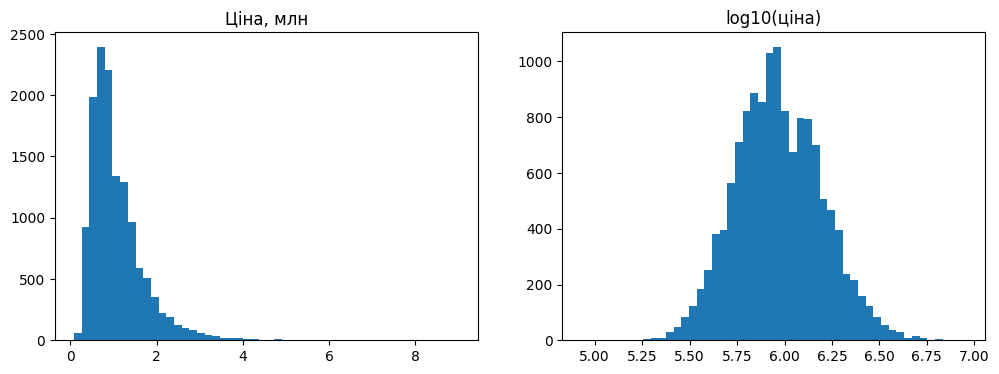

In [65]:
# Перегляд розподілу ціни
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(clean['Price'] / 1e6, bins=50)
ax[0].set_title("Ціна, млн")
ax[1].hist(np.log10(clean['Price']), bins=50)
ax[1].set_title("log10(ціна)")

plt.show()






Графік скошений вправо: більшість будинків вартістю 500–1500 млн.дол.

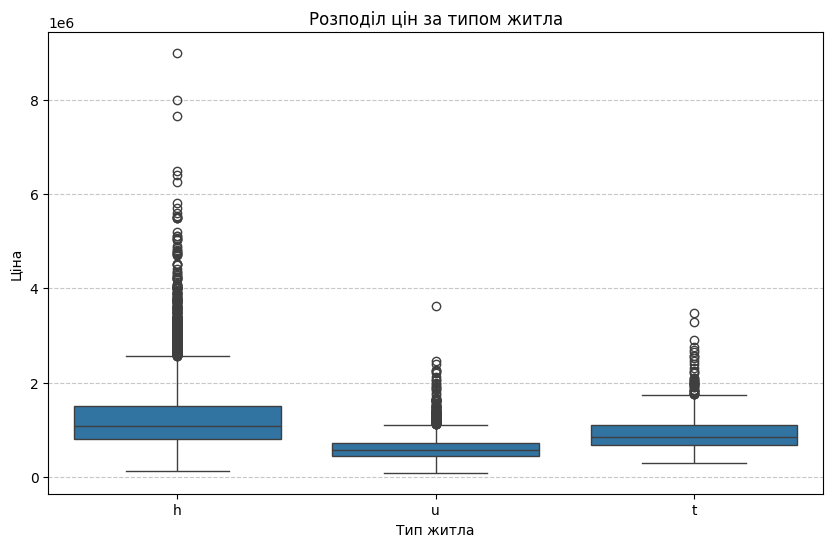

In [69]:
# Розподіл цін за типом житла
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='price', data=df)
plt.title('Розподіл цін за типом житла')
plt.xlabel('Тип житла')
plt.ylabel('Ціна')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Тип 'h' (будинки): Має найвищу медіанну ціну та найбільший розкид цін порівняно з іншими типами, а також значну кількість високих викидів.  

Тип 'u' (квартири): Має найнижчу медіанну ціну та найменший розкид цін.  

Тип 't' (таунхауси): Має медіанну ціну вищу, ніж 'u', але нижчу, ніж 'h', з помірним розкидом цін.  

Загалом, діаграма підтверджує, що будинки  зазвичай дорожчі та мають ширший діапазон цін, ніж квартири або таунхауси.

In [70]:
# Розглядаємо зв'язок числових ознак із ціною (кореляцію)

num = df.select_dtypes("number")
cor_price = num.corr()["price"].drop("price")
print(cor_price.sort_values(key=abs, ascending=False).round(3))


rooms            0.497
bedroom          0.476
bathroom         0.467
year_built      -0.332
car              0.280
lattitude       -0.213
longtitude       0.204
distance        -0.163
postcode         0.108
building_area    0.092
propertycount   -0.042
landsize         0.023
Name: price, dtype: float64


Найбільш сильно позитивно корельовані з ціною:
rooms (0.497)
bedroom (0.476)
bathroom (0.467). Це свідчить про те, що ці ознаки тісно пов'язані між собою та з ціною. Це логічно, оскільки кількість кімнат, спалень і ванних кімнат часто збільшується разом, і всі вони є ключовими факторами, що впливають на вартість нерухомості.  

Слабко корельовані: landsize (0.023) та propertycount (-0.042) мають дуже слабку кореляцію з ціною, що свідчить про те, що розмір ділянки або кількість об'єктів нерухомості в цьому районі не мають сильного впливу на ціну житла.